In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import Holt
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [34]:
df = pd.read_csv("/content/DUMMY DATASET.csv[1].csv")
df.head()

,,Daily_Website_Visitors,Avg_Time_On_Page_mins,Conversion_Rate,Avg_Order_Value_AUD,Daily_Sales_AUD
0,01-01-2023,907,2.91,0.0165,86.72,1297.81
1,02-01-2023,752,2.41,0.0197,92.07,1363.96
2,03-01-2023,832,2.70,0.0178,92.08,1363.67
3,04-01-2023,817,2.64,0.0221,92.35,1667.44
4,05-01-2023,712,3.07,0.0155,82.44,909.81


#FIXING THE DATE COLUMN

In [35]:
df = df.rename(columns={df.columns[0]: "Date"})

df["Date"] = pd.to_datetime(
    df["Date"],
    format="%d-%m-%Y")

df = df.set_index("Date")
df = df.sort_index()
df = df.asfreq("D")

df.head()

,Daily_Website_Visitors,Avg_Time_On_Page_mins,Conversion_Rate,Avg_Order_Value_AUD,Daily_Sales_AUD
Date,,,,,
2023-01-01,907,2.91,0.0165,86.72,1297.81
2023-01-02,752,2.41,0.0197,92.07,1363.96
2023-01-03,832,2.70,0.0178,92.08,1363.67
2023-01-04,817,2.64,0.0221,92.35,1667.44
2023-01-05,712,3.07,0.0155,82.44,909.81


In [36]:
#CHECKING THE DATA
print("Number of rows:", len(df))
print("\nMissing values:")
print(df.isnull().sum())

print("\nColumns:")
print(df.columns)

Number of rows: 731

Missing values:
Daily_Website_Visitors    0
Avg_Time_On_Page_mins     0
Conversion_Rate           0
Avg_Order_Value_AUD       0
Daily_Sales_AUD           0
dtype: int64

Columns:
Index(['Daily_Website_Visitors', 'Avg_Time_On_Page_mins', 'Conversion_Rate',
       'Avg_Order_Value_AUD', 'Daily_Sales_AUD'],
      dtype='object')


In [37]:
df.describe().round(4)

,Daily_Website_Visitors,Avg_Time_On_Page_mins,Conversion_Rate,Avg_Order_Value_AUD,Daily_Sales_AUD
count,731.0000,731.0000,731.0000,731.0000,731.0000
mean,1174.6703,3.1425,0.0252,97.5480,3017.0439
std,236.1755,0.4401,0.0049,9.0666,1291.9668
min,678.0000,1.9300,0.0133,73.3000,860.8200
25%,991.0000,2.8300,0.0214,91.1550,1922.6050
50%,1165.0000,3.1500,0.0251,97.5800,2860.5200
75%,1317.0000,3.4350,0.0287,103.4050,3879.6250
max,2699.0000,4.4500,0.0454,127.2100,10995.0800


DAILY SALES GRAPHS

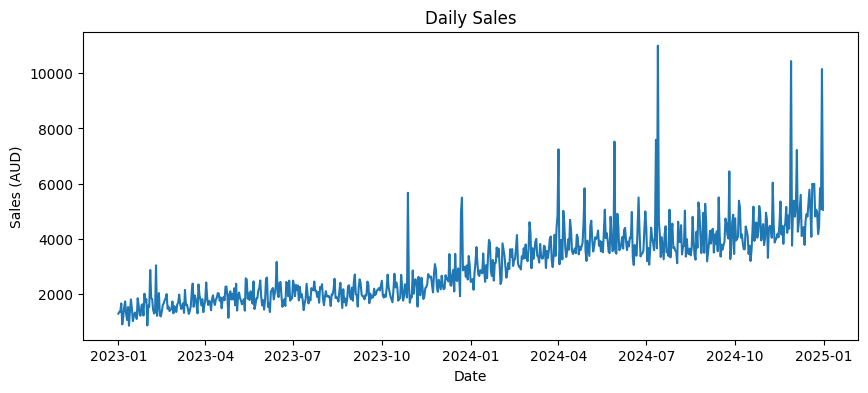

In [38]:
plt.figure(figsize=(10, 4))

plt.plot(df["Daily_Sales_AUD"])

plt.title("Daily Sales")
plt.xlabel("Date")
plt.ylabel("Sales (AUD)")

plt.show()

GRAPH OF WEBSITE VISITORS

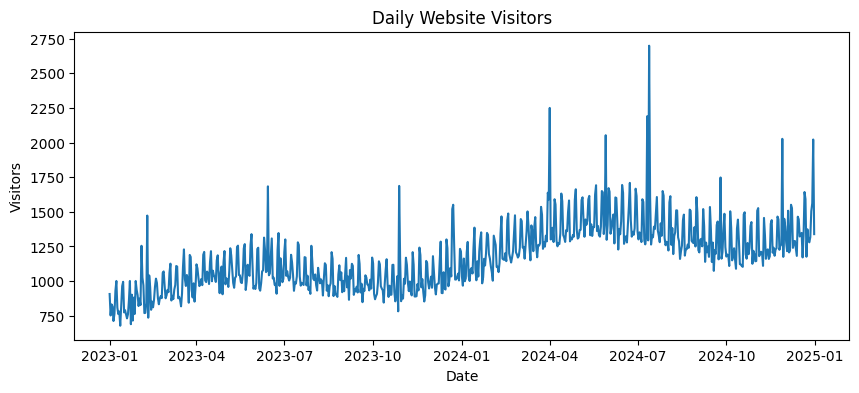

In [39]:
plt.figure(figsize=(10, 4))

plt.plot(df["Daily_Website_Visitors"])

plt.title("Daily Website Visitors")
plt.xlabel("Date")
plt.ylabel("Visitors")

plt.show()

30 DAYS ROLLING MEAN (ONE DAY IS EXCLUDED FROM THE BEGINNING AND NEW IS ADDED FROM THE END FIRST IT IS 1-30 THEN 2-31 THEN 3-32) AND ROLLING STD DEVIATION

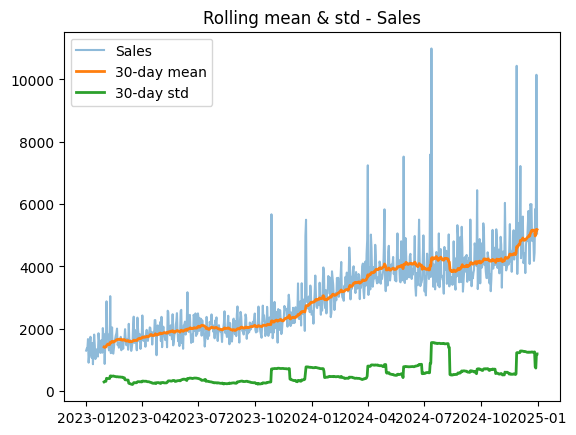

In [40]:
import os

#Rolling mean and std (30-day) for Sales
rolling_days = 30
plt.plot(df["Daily_Sales_AUD"], alpha=0.5, label="Sales")
plt.plot(df["Daily_Sales_AUD"].rolling(rolling_days).mean(), label=f"{rolling_days}-day mean", linewidth=2)
plt.plot(df["Daily_Sales_AUD"].rolling(rolling_days).std(), label=f"{rolling_days}-day std", linewidth=2)
plt.title("Rolling mean & std - Sales")
plt.legend()
OUT_DIR = "/content/"
plt.savefig(os.path.join(OUT_DIR, "rolling_sales.png"))
plt.show()

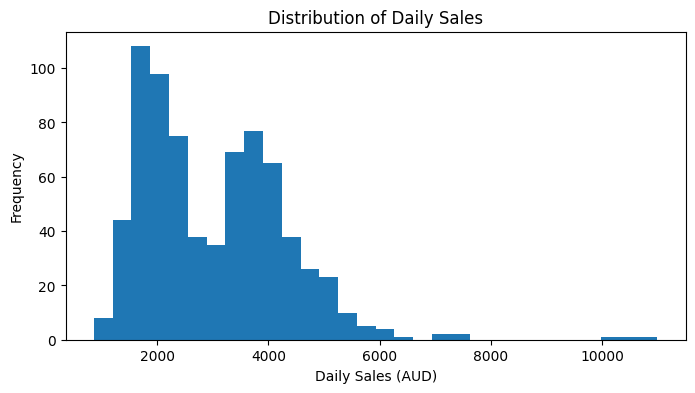

In [41]:
plt.figure(figsize=(8, 4))

plt.hist(df["Daily_Sales_AUD"], bins=30)

plt.title("Distribution of Daily Sales")
plt.xlabel("Daily Sales (AUD)")
plt.ylabel("Frequency")

plt.show()

Decomposition

For daily data, I would use 7 days first because your data clearly contains weekly behaviour.

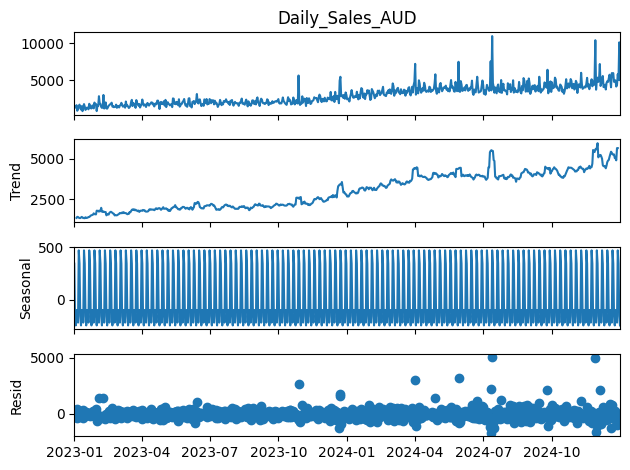

In [42]:
decomposition = seasonal_decompose(
    df["Daily_Sales_AUD"],
    model="additive",
    period=7)

decomposition.plot()

plt.show()

CORRELATION

In [43]:
variables = df[
    ["Daily_Sales_AUD","Daily_Website_Visitors","Avg_Time_On_Page_mins","Conversion_Rate",
    "Avg_Order_Value_AUD"]]

correlation = variables.corr()

correlation.round(3)

,Daily_Sales_AUD,Daily_Website_Visitors,Avg_Time_On_Page_mins,Conversion_Rate,Avg_Order_Value_AUD
Daily_Sales_AUD,1.000,0.869,0.713,0.908,0.695
Daily_Website_Visitors,0.869,1.000,0.668,0.663,0.410
Avg_Time_On_Page_mins,0.713,0.668,1.000,0.651,0.505
Conversion_Rate,0.908,0.663,0.651,1.000,0.663
Avg_Order_Value_AUD,0.695,0.410,0.505,0.663,1.000


FORECASTING

In [44]:
#TRAIN AND TEST
sales = df["Daily_Sales_AUD"]

train = sales.iloc[:-60]
test = sales.iloc[-60:]

print("Training observations:", len(train))
print("Testing observations:", len(test))

Training observations: 671
Testing observations: 60


Moving Average

In [45]:
ma_value = train.tail(7).mean()

print("7-day average:", round(ma_value, 2))

7-day average: 4373.28


In [46]:
ma_forecast = pd.Series(
    ma_value,
    index=test.index)

ma_forecast.head()

,0
Date,
2024-11-02,4373.278571
2024-11-03,4373.278571
2024-11-04,4373.278571
2024-11-05,4373.278571
2024-11-06,4373.278571


Holt Exponential Smoothing

In [53]:
#TRAINING
holt_model = Holt(train).fit(optimized=True)

In [54]:
holt_forecast = holt_model.forecast(60)

holt_forecast.index = test.index

holt_forecast.head()

,0
Date,
2024-11-02,4253.311601
2024-11-03,4255.768186
2024-11-04,4258.224771
2024-11-05,4260.681357
2024-11-06,4263.137942


EVALUATING MMOVING AVERAGE

In [55]:
ma_mae = mean_absolute_error(test, ma_forecast)

ma_rmse = np.sqrt(
    mean_squared_error(test, ma_forecast))

print("Moving Average MAE:", round(ma_mae, 2))
print("Moving Average RMSE:", round(ma_rmse, 2))

Moving Average MAE: 772.6
Moving Average RMSE: 1339.33


EVALUATING HOLT

In [56]:
holt_mae = mean_absolute_error(test, holt_forecast)

holt_rmse = np.sqrt(
    mean_squared_error(test, holt_forecast))

print("Holt MAE:", round(holt_mae, 2))
print("Holt RMSE:", round(holt_rmse, 2))

Holt MAE: 784.01
Holt RMSE: 1348.69


In [57]:
results = pd.DataFrame({
    "Model": ["Moving Average", "Holt"],
    "MAE": [ma_mae, holt_mae],
    "RMSE": [ma_rmse, holt_rmse]})

results.round(2)

,Model,MAE,RMSE
0,Moving Average,772.60,1339.33
1,Holt,784.01,1348.69


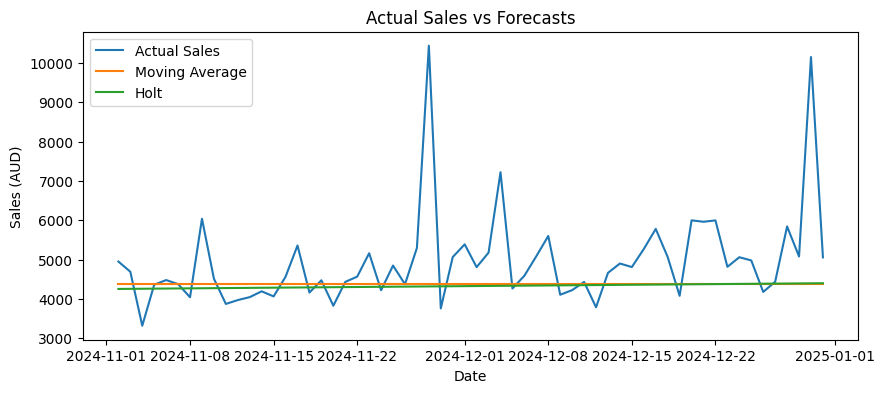

In [58]:
plt.figure(figsize=(10, 4))

plt.plot(test, label="Actual Sales")
plt.plot(ma_forecast, label="Moving Average")
plt.plot(holt_forecast, label="Holt")

plt.title("Actual Sales vs Forecasts")
plt.xlabel("Date")
plt.ylabel("Sales (AUD)")

plt.legend()
plt.show()